<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install nltk

In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn import ensemble

# For coherence score (requires gensim and nltk)
# pip install gensim nltk
import nltk
from nltk.tokenize import word_tokenize

print("Libraries loaded.")

n_samples_per_class = 800

Libraries loaded.


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap

# 1. Definição da URL pelo usuário (Substitua pela sua URL)
# Exemplo usando o clássico Wine Dataset do repositório UCI
url_dados = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Carregando os dados (ajuste o separador 'sep' se o seu arquivo for diferente)
df = pd.read_csv(url_dados, sep=";")

# Supondo que a última coluna seja o alvo (target) e as outras sejam as features
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Se o target for contínuo (como notas de 0 a 10) e queremos classificação,
# vamos binarizar apenas para o exemplo rodar perfeitamente como Classificador
y = (y >= 7).astype(int)

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---

# 2. Construção do Pipeline de Pré-processamento
# Identificando colunas numéricas (neste dataset todas são numéricas)
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche valores ausentes com a mediana
    ('scaler', StandardScaler())                  # Padroniza as features (média=0, variância=1)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Pipeline final unindo Pré-processamento + Modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# ---

# 3. Ajuste de Hiperparâmetros com GridSearchCV
# Atenção ao prefixo 'classifier__' para indicar que os parâmetros pertencem ao Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [5, 10]
}

print("Iniciando a busca de hiperparâmetros com GridSearchCV...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}\n")

# ---

# 4. Avaliação do Modelo (Classification Report)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Relatório de Classificação nos dados de teste:")
print(classification_report(y_test, y_pred))

# ---

# 5. Interpretação com SHAP
print("Iniciando a interpretação com SHAP...")

# Importante: O SHAP precisa dos dados transformados para explicar o Random Forest corretamente.
# Vamos extrair apenas o passo de pré-processamento do nosso pipeline fitado.
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# Convertendo de volta para DataFrame para manter o nome das colunas nos gráficos do SHAP
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=numeric_features)

# Extraindo o modelo de árvore já treinado de dentro do pipeline
rf_model = best_model.named_steps['classifier']

# Criando o explicador SHAP específico para árvores (TreeExplainer)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_transformed_df)

# Se for uma classificação binária, o SHAP gera valores para ambas as classes [0, 1].
# Vamos pegar os valores correspondentes à classe positiva (índice 1).
if isinstance(shap_values, list) or len(shap_values.shape) == 3:
    # Dependendo da versão do SHAP, a indexação muda levemente
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values


Iniciando a busca de hiperparâmetros com GridSearchCV...
Melhores parâmetros encontrados: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}

Relatório de Classificação nos dados de teste:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       277
           1       0.90      0.60      0.72        43

    accuracy                           0.94       320
   macro avg       0.92      0.80      0.84       320
weighted avg       0.94      0.94      0.93       320

Iniciando a interpretação com SHAP...


Gerando gráfico SHAP (feche a janela do gráfico para encerrar o script se rodar localmente)...


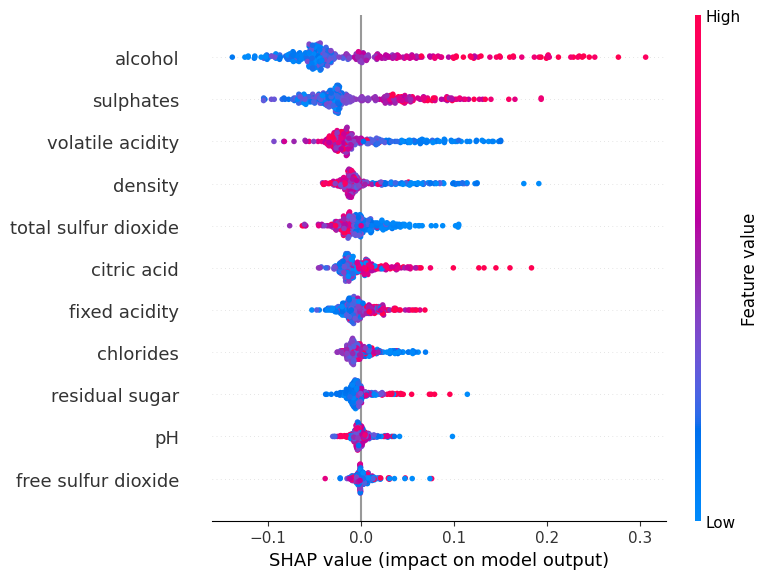

In [20]:

# Gerando o gráfico de resumo (Summary Plot)
print("Gerando gráfico SHAP (feche a janela do gráfico para encerrar o script se rodar localmente)...")
shap.summary_plot(shap_values_class_1, X_test_transformed_df)

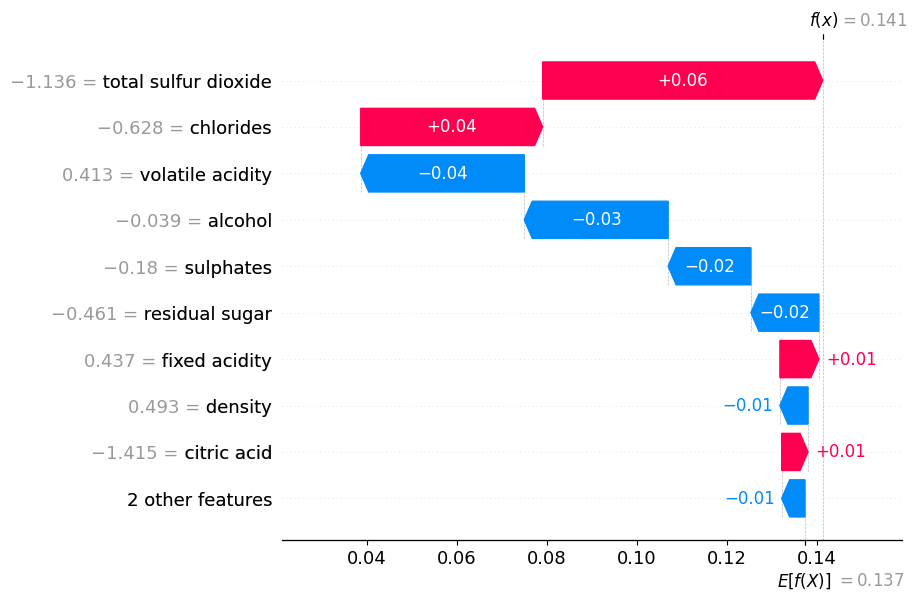

In [21]:
# 1. Escolha o índice da amostra que deseja analisar (ex: primeira linha do dataset de teste)
indice_amostra = 10

# 2. Gerar o gráfico Waterfall para essa amostra específica
# Usamos .plots.waterfall passando os valores shap daquela linha
# plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_class_1[indice_amostra], max_display=10)

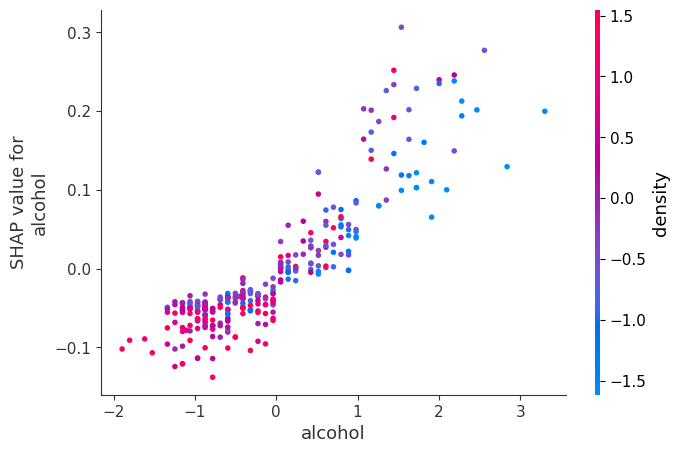

In [22]:
# ---

# 6. SHAP Dependence Plot

# O Dependence Plot analisa uma feature específica em profundidade.
# Ele mostra a relação entre o valor da feature (eixo X) e seu impacto na previsão (SHAP value, eixo Y).
# O SHAP, por padrão, colore os pontos com base em uma segunda feature que tem a interação mais forte com a feature principal.

feature_analisada = 'alcohol'

# Criamos o gráfico de dependência
# shap_values_class_1: o array de valores SHAP (classe positiva)
# X_test_transformed_df: o DataFrame com as features de teste transformadas (com os nomes corretos)
# O SHAP tentará adivinhar a melhor feature de interação ('interaction_index="auto"')
shap.dependence_plot(
    feature_analisada,
    shap_values_class_1.values, # .values extrai o array numpy do objeto Explainer
    X_test_transformed_df,
    # interaction_index="auto",
    interaction_index='density',
    show=False # show=False para customizar com matplotlib
)


In [23]:
import nltk
import requests
from nltk.corpus import stopwords

# Garante o download da lista base do NLTK (roda apenas uma vez)
nltk.download('stopwords', quiet=True)

def baixar_stopwords_github(url):
    """Função auxiliar para baixar arquivos de texto puro do GitHub"""
    try:
        response = requests.get(url)
        response.raise_for_status() # Garante que o download foi bem-sucedido
        # Divide o texto por quebras de linha e limpa espaços extras
        palavras = [linha.strip().lower() for list_linha in response.text.split('\n') if (linha := list_linha.strip())]
        return set(palavras)
    except Exception as e:
        print(f"Erro ao baixar da URL {url}: {e}")
        return set()

# 1. Carregar a lista base do NLTK para português
stopwords_nltk = set(stopwords.words('portuguese'))
print(f"Palavras na lista original do NLTK: {len(stopwords_nltk)}")

# 2. URLs de listas públicas e consagradas no GitHub (formatos Raw/Texto Puro)
# Lista 1: Stopwords ISO (uma das mais completas do GitHub)
url_iso = "https://raw.githubusercontent.com/stopwords-iso/stopwords-pt/master/stopwords-pt.txt"

# Lista 2: Uma lista estendida muito utilizada em projetos de NLP em PT-BR
url_extended = "https://raw.githubusercontent.com/LanguageTools/LanguageTool/master/languagetool-language-modules/pt/src/main/resources/org/languagetool/resource/pt/stopwords.txt"

print("Baixando listas adicionais do GitHub...")
stopwords_iso = baixar_stopwords_github(url_iso)
stopwords_extended = baixar_stopwords_github(url_extended)

# 3. Unir todas as listas usando a teoria de conjuntos (Set) para evitar duplicatas
stopwords_completa = stopwords_nltk.union(stopwords_iso).union(stopwords_extended)

# 4. Opcional, mas altamente recomendado: Adicionar versões sem acento
# Para evitar que palavras como "também" passem no filtro se o usuário digitar "tambem"
import unicodedata

def remover_acentos(texto):
    return "".join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

stopwords_sem_acento = {remover_acentos(palavra) for palavra in stopwords_completa}
stopwords_final = stopwords_completa.union(stopwords_sem_acento)

# --- RESULTADOS ---
print(f"Palavras adicionadas da ISO: {len(stopwords_iso)}")
print(f"Palavras adicionadas da LanguageTool: {len(stopwords_extended)}")
print(f"Total final de stopwords combinadas (com/sem acento): {len(stopwords_final)}")

# Convertendo para lista ordenada caso queira salvar ou visualizar
lista_final_ordenada = sorted(list(stopwords_final))

# Exemplo de visualização de algumas palavras na lista
print("\nExemplo de 20 palavras da sua nova lista:")
print(lista_final_ordenada[:20])

# Como usar no seu projeto de texto (exemplo):
# tfidf = TfidfVectorizer(stop_words=lista_final_ordenada)

Palavras na lista original do NLTK: 207
Baixando listas adicionais do GitHub...
Erro ao baixar da URL https://raw.githubusercontent.com/LanguageTools/LanguageTool/master/languagetool-language-modules/pt/src/main/resources/org/languagetool/resource/pt/stopwords.txt: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/LanguageTools/LanguageTool/master/languagetool-language-modules/pt/src/main/resources/org/languagetool/resource/pt/stopwords.txt
Palavras adicionadas da ISO: 560
Palavras adicionadas da LanguageTool: 0
Total final de stopwords combinadas (com/sem acento): 627

Exemplo de 20 palavras da sua nova lista:
['a', 'acerca', 'adeus', 'agora', 'ai', 'ainda', 'alem', 'algmas', 'algo', 'algumas', 'alguns', 'ali', 'além', 'ambas', 'ambos', 'ano', 'anos', 'antes', 'ao', 'aonde']


In [24]:
import pandas as pd

def loadHateBR(n_samples=None):
  # Use the raw GitHub URL for direct CSV access
  df = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv', sep=',')

  # Assuming 'text' column contains the document text and 'label' is the target.
  # Adjust column names if they are different in the actual dataset.

  if n_samples is not None:
    # Group by label and sample n_samples from each class
    df = df.groupby('label').apply(lambda x: x.sample(n=min(len(x), n_samples), random_state=42)).reset_index(drop=True)

  data = df['preprocessed_news'].values
  target = (df['label'] == 'true').astype(int).values
  return data, target


data, target = loadHateBR(n_samples=n_samples_per_class)

print(data.shape)
print(target.shape)

(1600,)
(1600,)


In [25]:
import pandas as pd
import nltk
from nltk.corpus import mac_morpho
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Downloads necessários do NLTK (incluindo o corpus em português)
nltk.download('mac_morpho', quiet=True)

# 2. Treinando um Tagged rápido para Português usando o MacMorpho
# O NLTK não vem com um tagger de português pronto "out-of-the-box", então criamos um UnigramTagger baseado no MacMorpho
print("Treinando o etiquetador (POS Tagger) para Português...")
sentences = mac_morpho.tagged_sents()
portuguese_tagger = nltk.UnigramTagger(sentences)

# 4. Função para extrair apenas adjetivos de um texto
def extrair_adjetivos(textos_lista, tagger):
    adjetivos_unicos = set()

    for texto in textos_lista:
        # Tokeniza o texto em palavras individuais
        palavras = nltk.word_tokenize(texto.lower(), language='portuguese')
        # Aplica o POS Tagging
        tags = tagger.tag(palavras)

        # No MacMorpho, adjetivos são marcados estritamente como 'ADJ'
        for palavra, tag in tags:
            if tag == 'ADJ' and palavra.isalpha(): # Garante que é palavra e não pontuação
                adjetivos_unicos.add(palavra)

    return list(adjetivos_unicos)


Treinando o etiquetador (POS Tagger) para Português...


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer


flag_adj = True

X = data
y = target

# Divisão em treino e teste (com estratificação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)



if flag_adj:
  # Criando o nosso vocabulário restrito
  vocabulario_adjetivos = extrair_adjetivos(X_train, portuguese_tagger)
  print(f"\nVocabulário de adjetivos detectados ({len(vocabulario_adjetivos)}):")
else:
  vocabulario_adjetivos = None


# ---

# 2. Construção do Pipeline (TF-IDF + Random Forest)
# Limitamos max_features para o SHAP processar rápido e o modelo não dar overfit em textos curtos
pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(
        max_features= 500 if not flag_adj else None,
        vocabulary=vocabulario_adjetivos if flag_adj else None,
        stop_words=lista_final_ordenada
    )),
    ('classifier', RandomForestClassifier(random_state=42))
])

# ---

# 3. Ajuste de Hiperparâmetros com GridSearchCV
param_grid = {
    'classifier__n_estimators': [10, 50],
    'classifier__max_depth': [5, 10]
}

print("Iniciando GridSearchCV para o modelo de texto...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}\n")

# ---

# 4. Avaliação do Modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# ---

# 5. Aplicando o SHAP para Texto
print("Preparando dados para o SHAP...")

# Passo crucial: Transformar o texto do teste usando o TF-IDF já treinado do pipeline
tfidf_transformer = best_model.named_steps['tfidf']
X_test_transformed = tfidf_transformer.transform(X_test).toarray() # SHAP precisa de array denso

# Recuperar o nome das palavras (tokens) para servirem como colunas
feature_names = tfidf_transformer.get_feature_names_out()

# Criar um DataFrame para que os gráficos do SHAP mostrem as palavras em vez de índices numéricos
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Extrair o classificador treinado
rf_model = best_model.named_steps['classifier']

# Inicializar o TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_df)


# Se for uma classificação binária, o SHAP gera valores para ambas as classes [0, 1].
# Vamos pegar os valores correspondentes à classe positiva (índice 1).
if isinstance(shap_values, list) or len(shap_values.shape) == 3:
    # Dependendo da versão do SHAP, a indexação muda levemente
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values



Vocabulário de adjetivos detectados (2011):
Iniciando GridSearchCV para o modelo de texto...
Melhores parâmetros: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       240
           1       0.92      0.80      0.85       240

    accuracy                           0.86       480
   macro avg       0.87      0.86      0.86       480
weighted avg       0.87      0.86      0.86       480

Preparando dados para o SHAP...


In [27]:

# Se for uma classificação binária, o SHAP gera valores para ambas as classes [0, 1].
# Vamos pegar os valores correspondentes à classe positiva (índice 1).
if isinstance(shap_values, list) or len(shap_values.shape) == 3:
    # Dependendo da versão do SHAP, a indexação muda levemente
    shap_values_class_1 = shap_values[:, :, 1]
else:
    shap_values_class_1 = shap_values


Gerando gráfico SHAP (feche a janela do gráfico para encerrar o script se rodar localmente)...


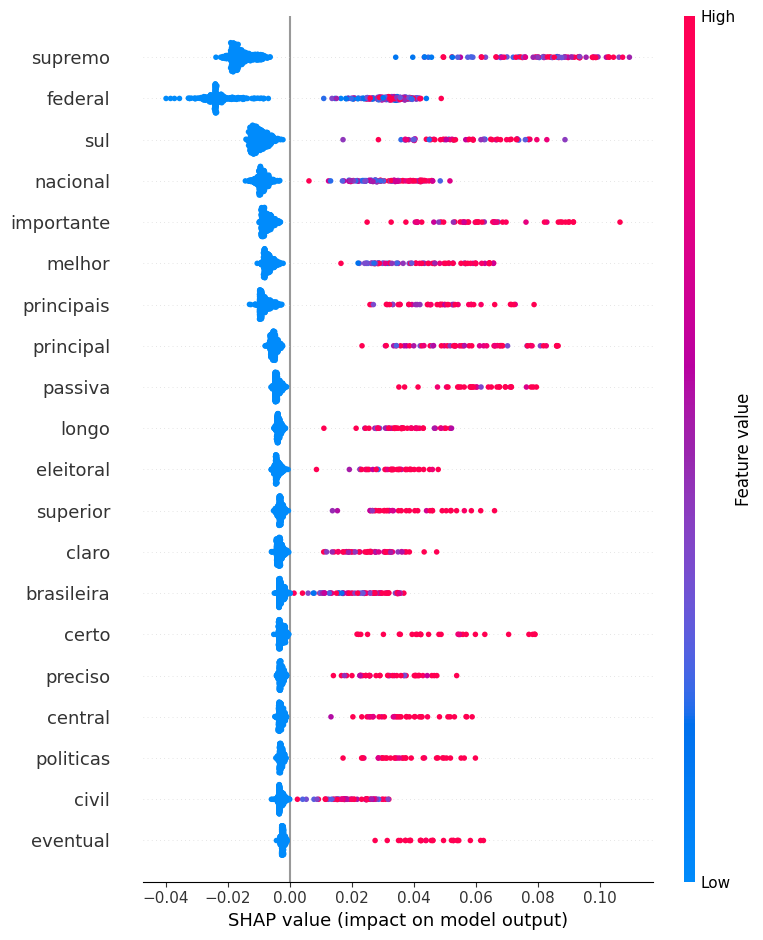

In [28]:

# Gerando o gráfico de resumo (Summary Plot)
print("Gerando gráfico SHAP (feche a janela do gráfico para encerrar o script se rodar localmente)...")
shap.summary_plot(shap_values_class_1, X_test_df)

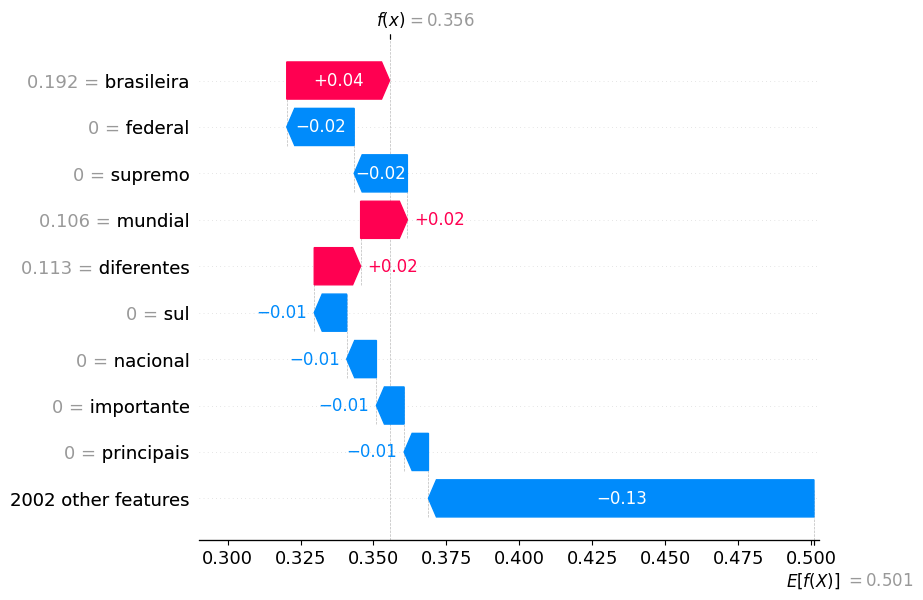

In [29]:
# 1. Escolha o índice da amostra que deseja analisar (ex: primeira linha do dataset de teste)
indice_amostra = 20

# 2. Gerar o gráfico Waterfall para essa amostra específica
# Usamos .plots.waterfall passando os valores shap daquela linha
# plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_class_1[indice_amostra], max_display=10)

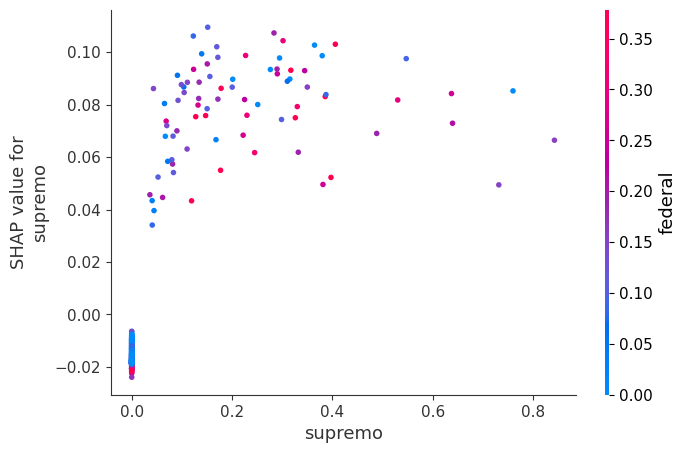

In [30]:
# ---

# 6. SHAP Dependence Plot

# O Dependence Plot analisa uma feature específica em profundidade.
# Ele mostra a relação entre o valor da feature (eixo X) e seu impacto na previsão (SHAP value, eixo Y).
# O SHAP, por padrão, colore os pontos com base em uma segunda feature que tem a interação mais forte com a feature principal.

feature_analisada = 'supremo'

# Criamos o gráfico de dependência
# shap_values_class_1: o array de valores SHAP (classe positiva)
# X_test_transformed_df: o DataFrame com as features de teste transformadas (com os nomes corretos)
# O SHAP tentará adivinhar a melhor feature de interação ('interaction_index="auto"')
shap.dependence_plot(
    feature_analisada,
    shap_values_class_1.values, # .values extrai o array numpy do objeto Explainer
    X_test_df,
    # interaction_index="auto",
    interaction_index='federal',
    show=False # show=False para customizar com matplotlib
)
